# Plotting data and models with stat_tool

## This notebook illustates how stat_tool transparently relies on matplotlib for graphical representations of data and models

Most classes have a *plot* method, or equivalently can be the argument of the *Plot* function, which adapts the graphical representation to each object. In some rare cases, options allow users to choose between several representations.

## Plotting histograms

We first load a data set (chene_sessile.vec)    

In [1]:
from openalea.stat_tool import (get_shared_data,
                                Histogram,
                                Binomial,
                                NegativeBinomial,
                                Poisson,
                                Mixture,
                                Convolution,
                                Compound,
                                Estimate,
                                set_seed,
                                ExtractDistribution
)
from openalea.stat_tool.data_transform import (SelectVariable, 
                                               SelectIndividual, 
                                               Merge,
                                               MergeVariable,
                                               Shift,
                                               ValueSelect
)
from openalea.stat_tool.output import Plot
from openalea.stat_tool.vectors import Vectors
from openalea.stat_tool.cluster import Transcode
from openalea.stat_tool._stat_tool import _MultivariateMixture

vec = Vectors(get_shared_data("chene_sessile.vec"))

Running cmake --build & --install in /home/jdurand/devlp/Git/openalea/stat_tool/build
Running cmake --build & --install in /home/jdurand/devlp/Git/openalea/sequence_analysis/build


The method Vectors.extract extracts the histogram of a variable, here variable 2. This histogram can be represented using the Plot function.

In [2]:
H = vec.extract(2)

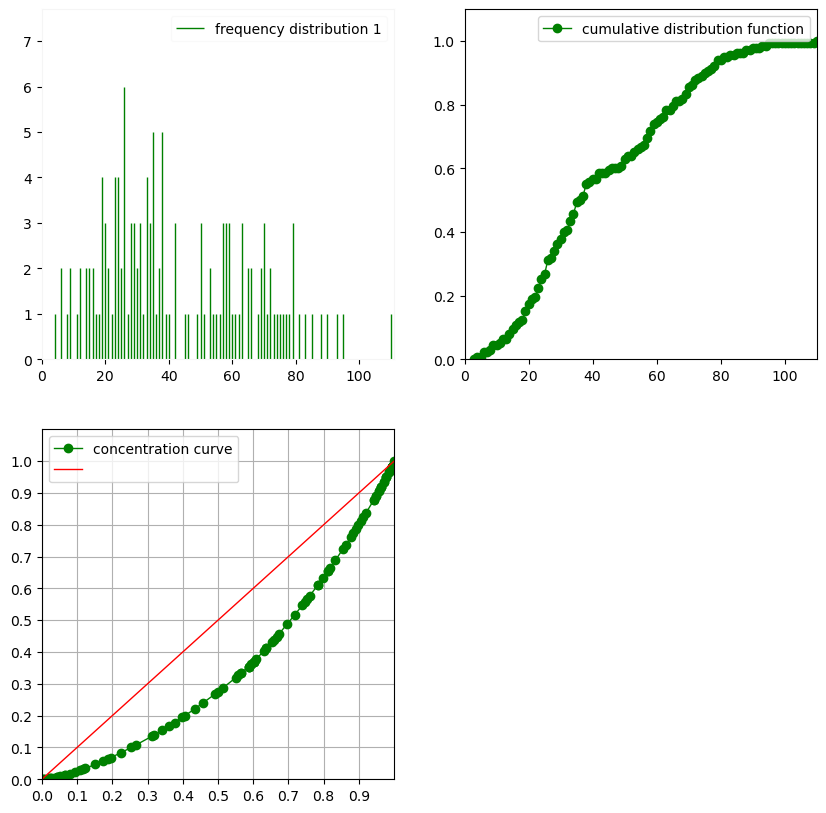

In [3]:
Plot(H)

This displays the barplot, the empirical distribution function and concentration curve (also known as Lorenz curve). This is equivalent to using the plot() method:

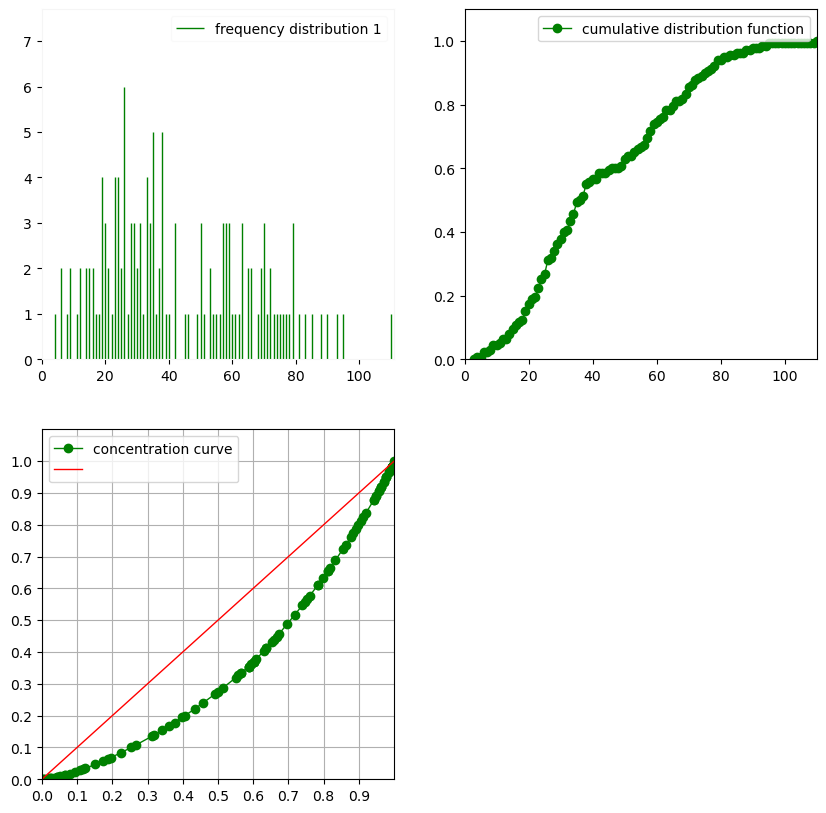

In [4]:
H.plot()

The method and function create an object that contains the data to be represented, axis, legend and styles. It then calls matplotlib to show the rendering.

It is possible to add a title by using the Title optional argument:

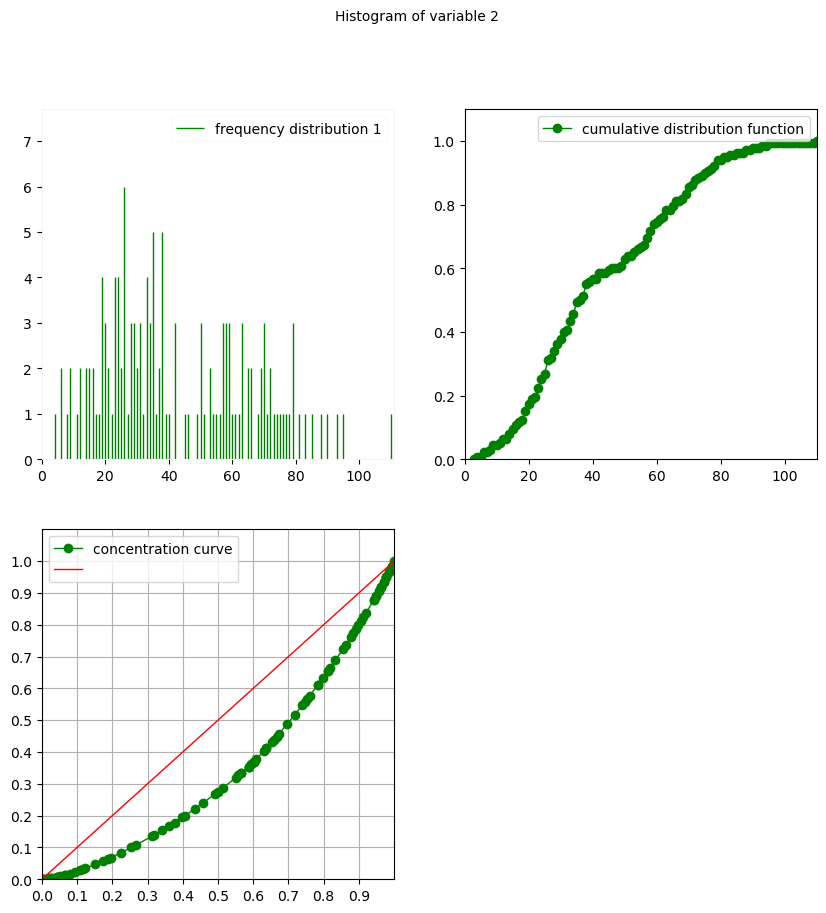

In [5]:
Plot(H, Title="Histogram of variable 2")

## Plotting Vectors

Calling the Plot function on a Vectors object represent the histograms of each marginal, i.e. the data along each dimension, plus two-dimensional plots of the data for each pair $(v_1, v_2)$ of variables with $v_1 < v_2$.   
Since Plot relies on matplotlib, you may use standard options from matplotlib to set the size and resolution of figures.

/home/jdurand/devlp/Git/openalea/stat_tool/src/openalea/stat_tool/plot.py:221: UserWarning: Ignoring specified arguments in this call because figure with num: 1 already exists
  f1 = pylab.figure(fig_id, figsize=(10, 10))


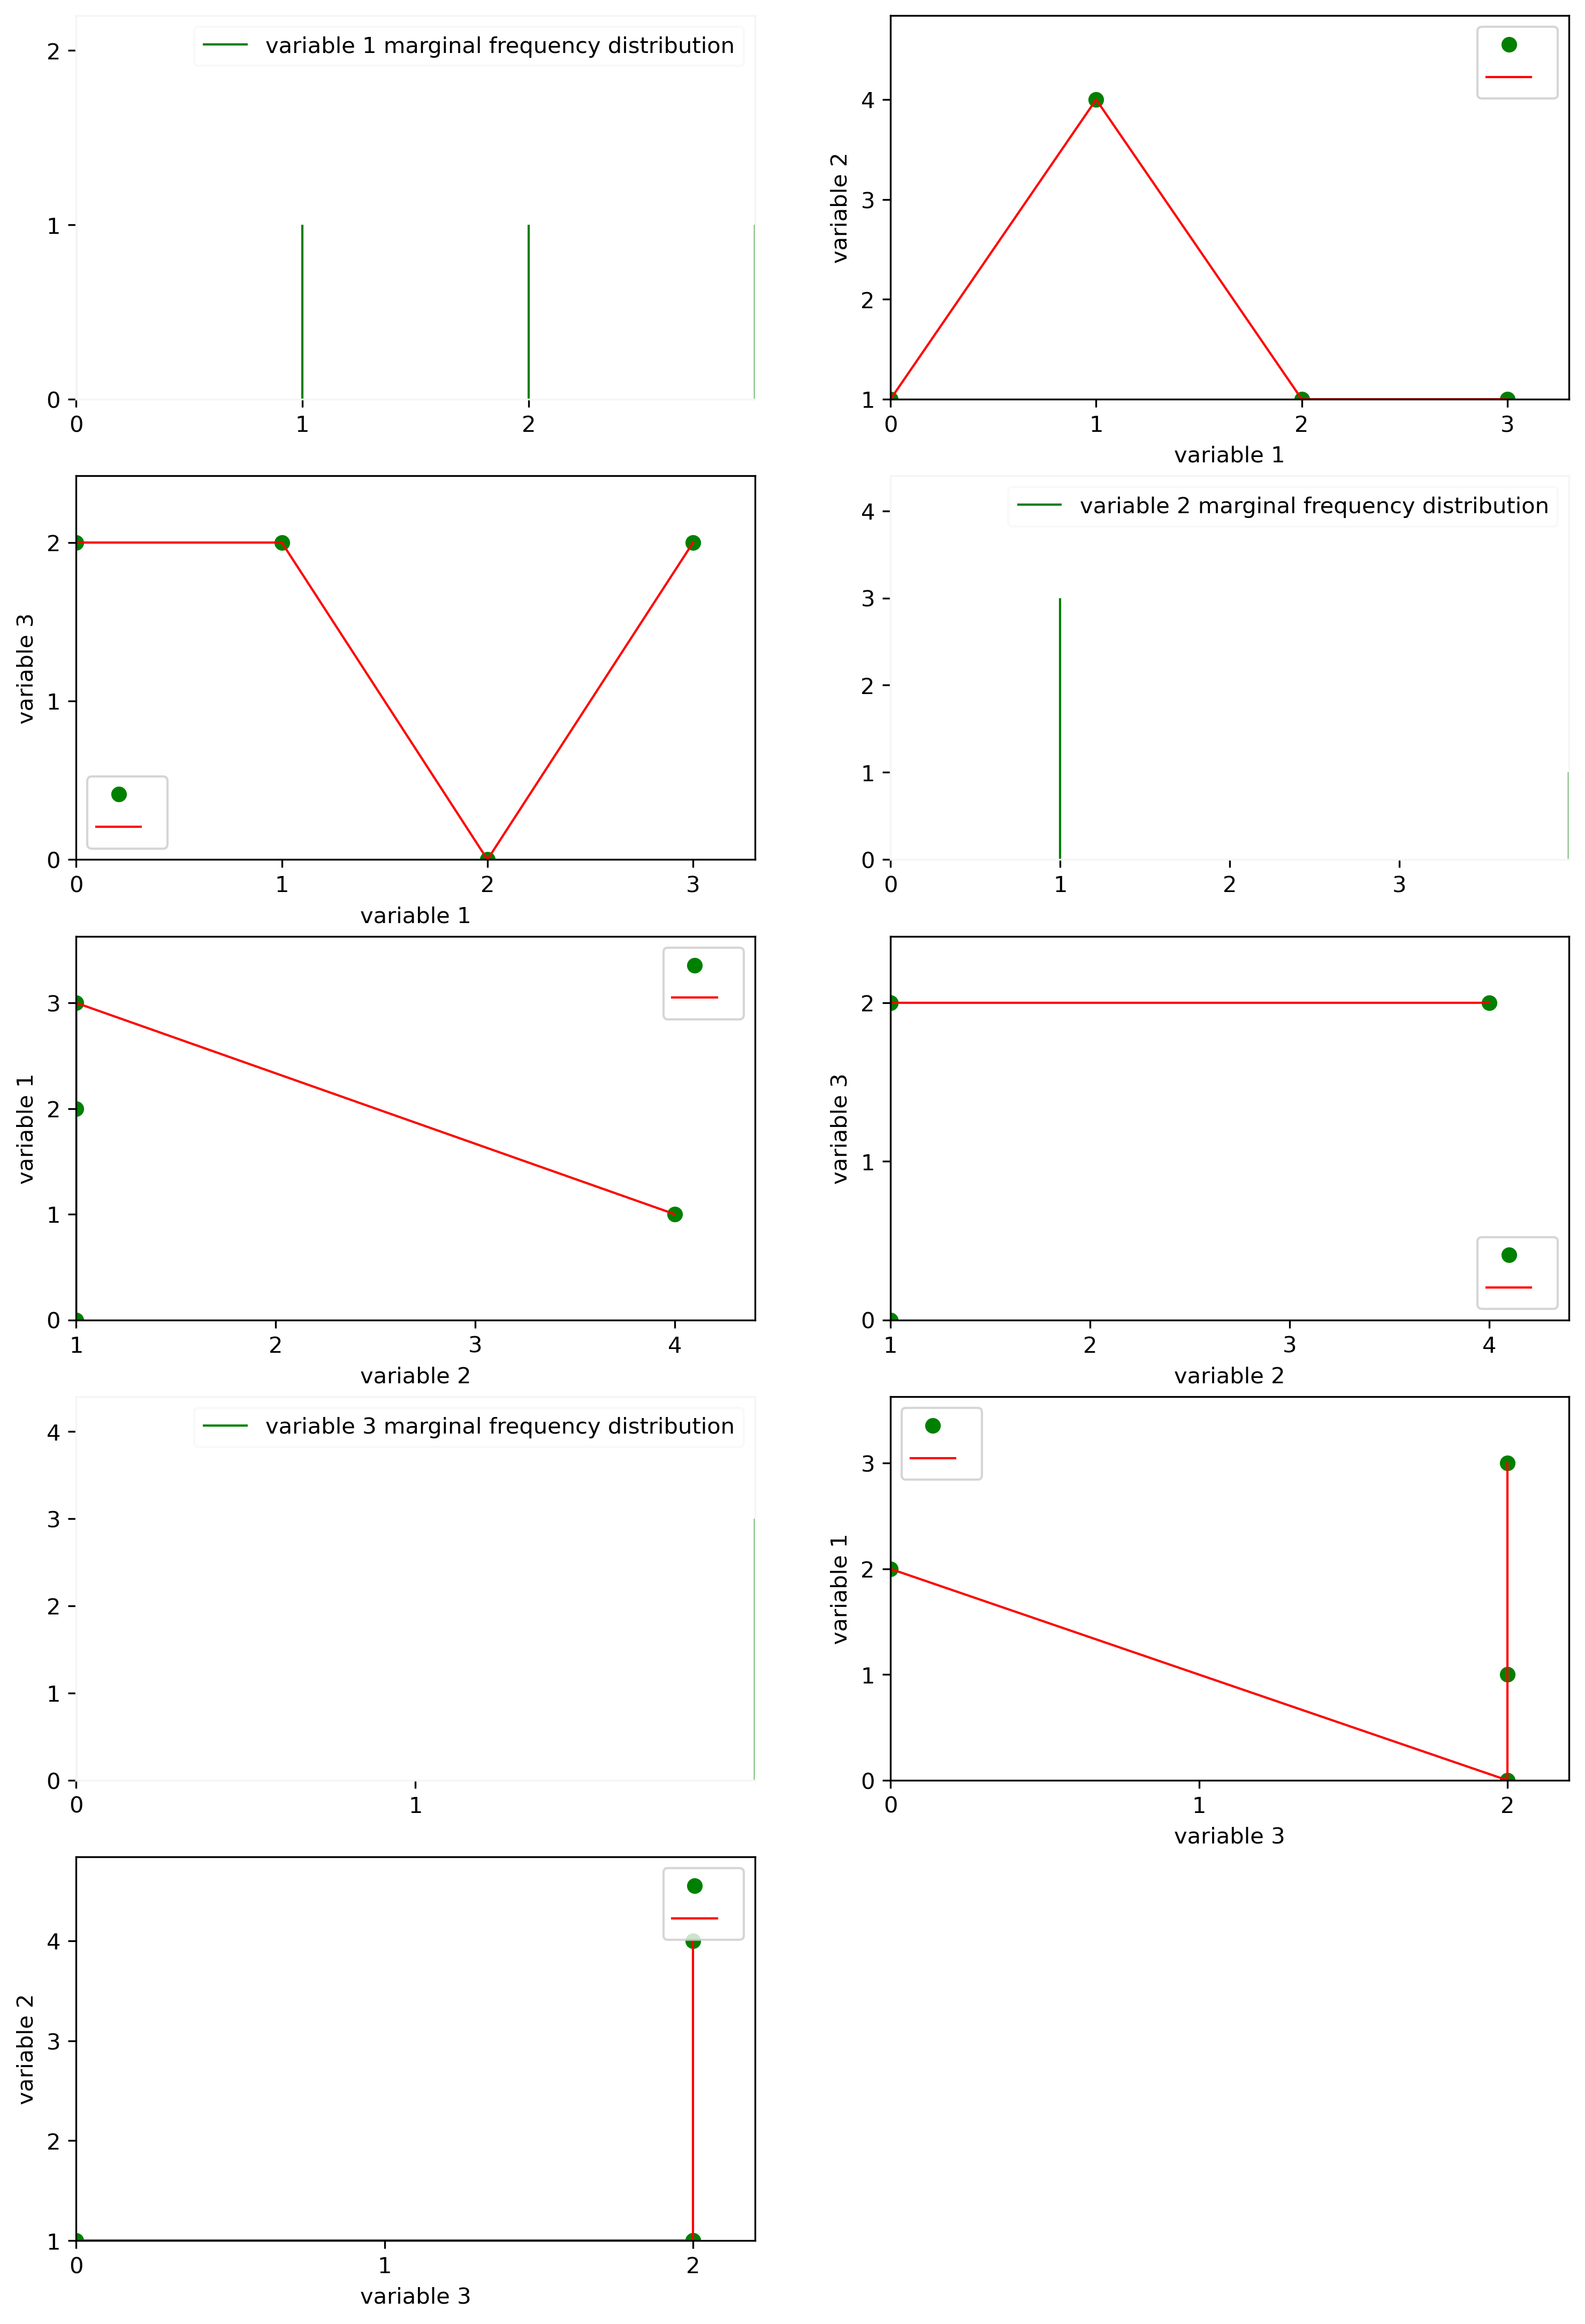

In [6]:
vec = Vectors([[0, 1, 2], [1, 4, 2], [2, 1, 0], [3, 1, 2]])

from matplotlib import pyplot as plt
fig = plt.figure(figsize=(12,18), dpi= 300)

Plot(vec)

## Plotting Distributions

Using Plot on a Distribution yields the curves of the probability mass function, cumulative distribution function and concentration curve.

In [7]:
P = Poisson(5, 10.8)

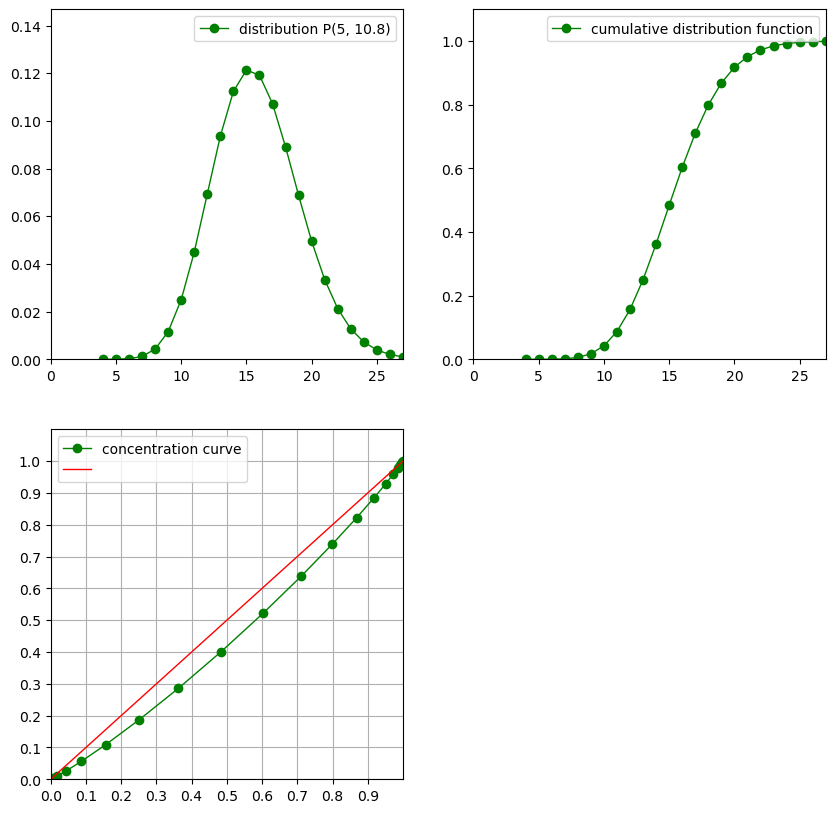

In [8]:
Plot(P)

A specific feature of Stat_tool is the association between Distribution and Histogram objects whenever an Histogram comes from a Distribution (simulation) or a Distribution comes from an Histogram (estimation). In both cases, plotting the objects involves some object with class _DiscreteDistributionData combining data and model within a single representation:

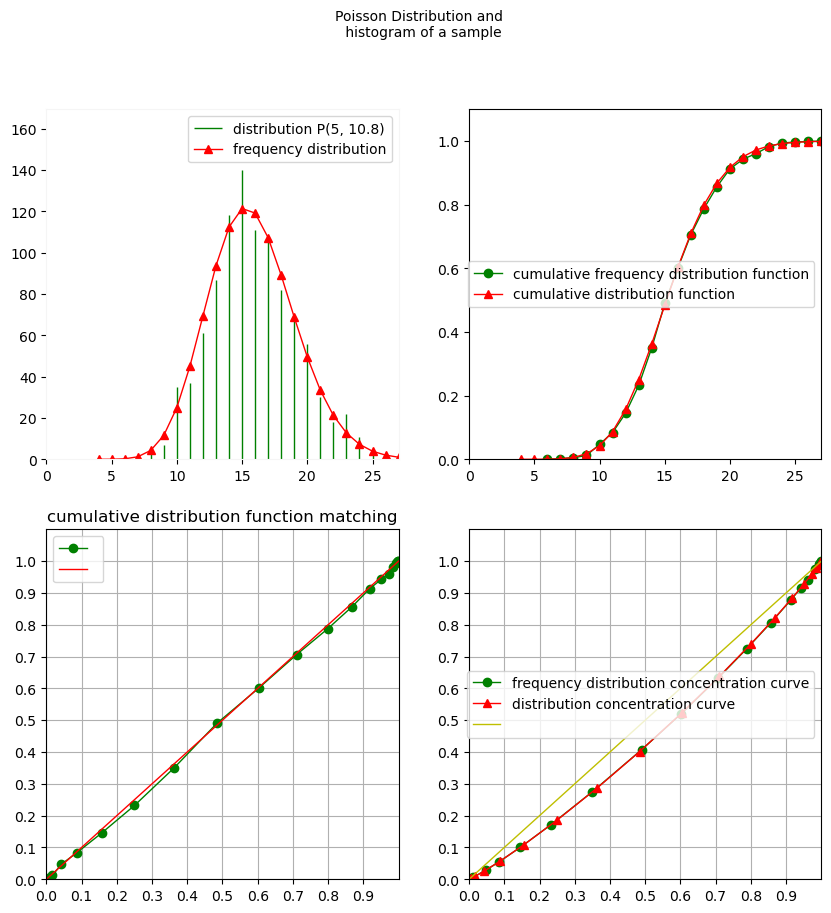

In [9]:
set_seed(0)
simulation_P = P.simulate(1000)
Plot(simulation_P, Title="Poisson Distribution and \n histogram of a sample")

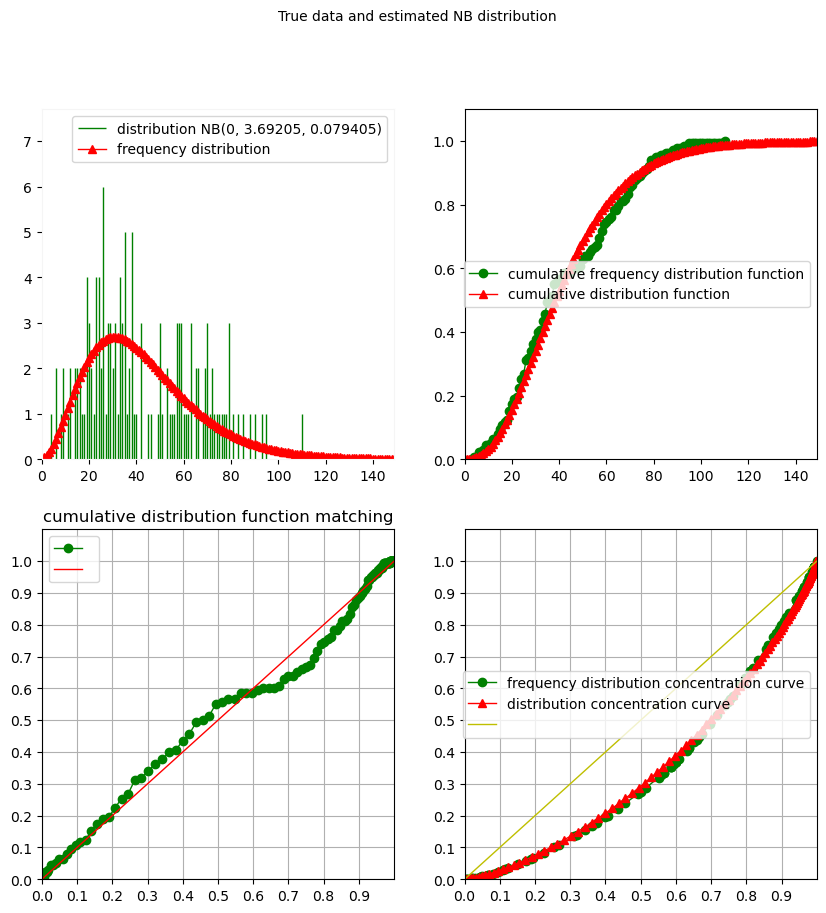

In [10]:
est_H = Estimate(H, "NEGATIVE_BINOMIAL")
Plot(est_H, Title = "True data and estimated NB distribution")

## Plotting Mixtures

Mixtures are particular cases of distributions.   
Using the Plot function on mixture yields a representation of the probability mass function of the mixture, but also that of each component, rescale by the mixture weights:

In [11]:
D1 = NegativeBinomial(0, 1, 0.1)
D2 = Poisson(0, 10.5)
D3 = Poisson(2, 5.2)
M = Mixture(0.4, D1, 0.4, D2, 0.2, D3)

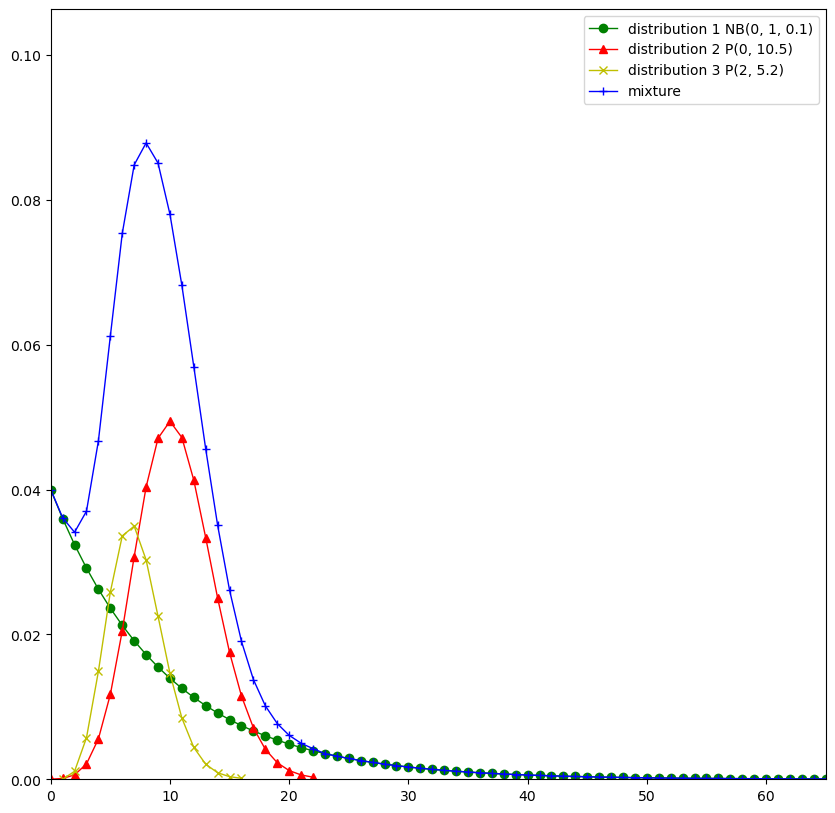

In [12]:
Plot(M)

Using plot on a object issued from simulating a mixture yields the usual histogram, probability mass function and cumulative distribution function, but also the weights, empirical proportions of the mixture and the representation of each component:

In [13]:
set_seed(0)
simulation_M = M.simulate(400)

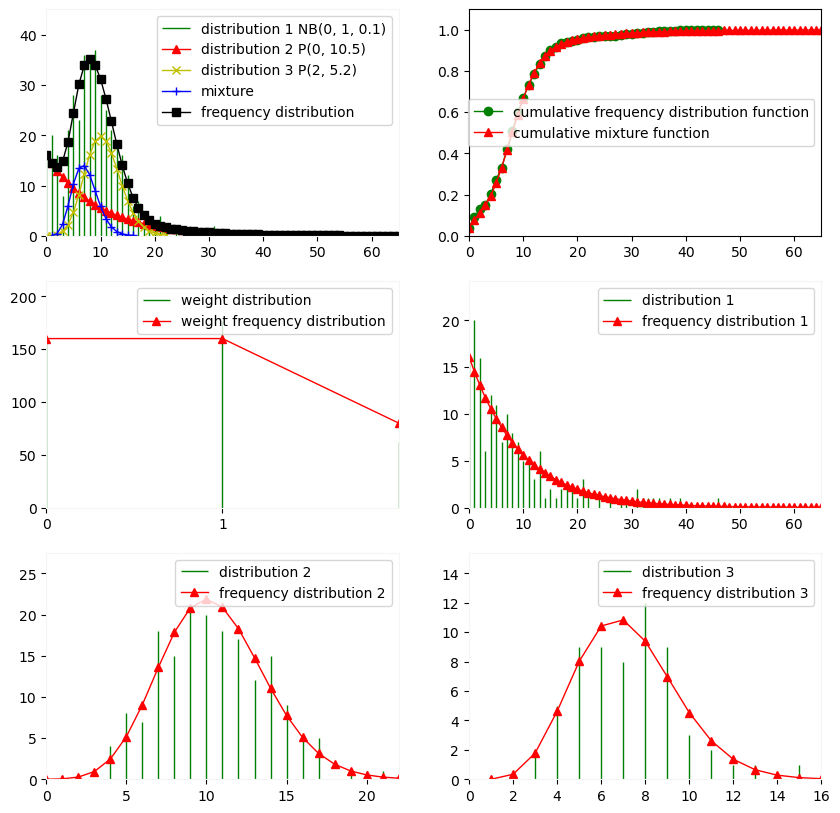

In [14]:
Plot(simulation_M)

This principle also holds when estimating a mixture from a sample but in this case, the empirical weight and component histograms are issued from the clustering, meaning that a label is assigned to each observation and graphical representation are produced for each label and their associated data:

In [15]:
M_est = Estimate(simulation_M, "Mixture", "NB", "B", "B")

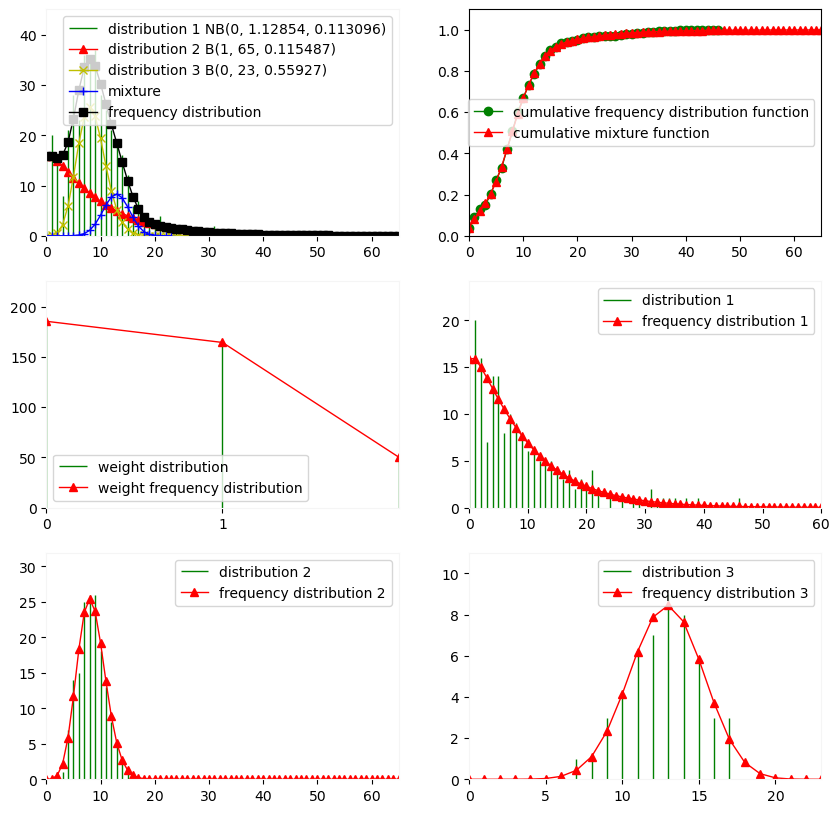

In [16]:
Plot(M_est)

## Plotting Multivariate Mixtures

In the case of multivariate mixtures, each variable (i.e., each marginal) has a mixture distribution, so the Plot function represents the (common) weights and each marginal with its components.

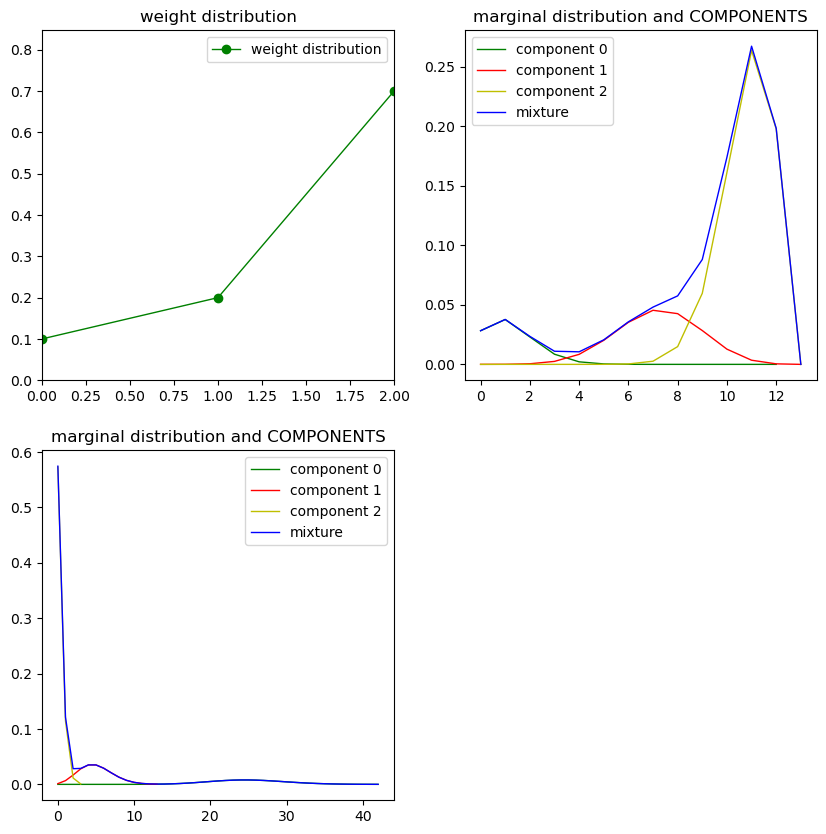

In [18]:
d11 = Binomial(0, 12, 0.1)
d12 = Binomial(0, 12, 0.6)
d13 = Binomial(0, 12, 0.9)

d21 = Poisson(0, 25.0)
d22 = Poisson(0, 5.0)
d23 = Poisson(0, 0.2)

MultiM = _MultivariateMixture([0.1, 0.2, 0.7], [[d11, d21], [d12, d22], [d13, d23]])
Plot(MultiM)

In [19]:
set_seed(0)
simulation_MultiM = MultiM.simulate(400)

The same principle holds for data simulated from multivariate mixtures...

Warning. Empty data.


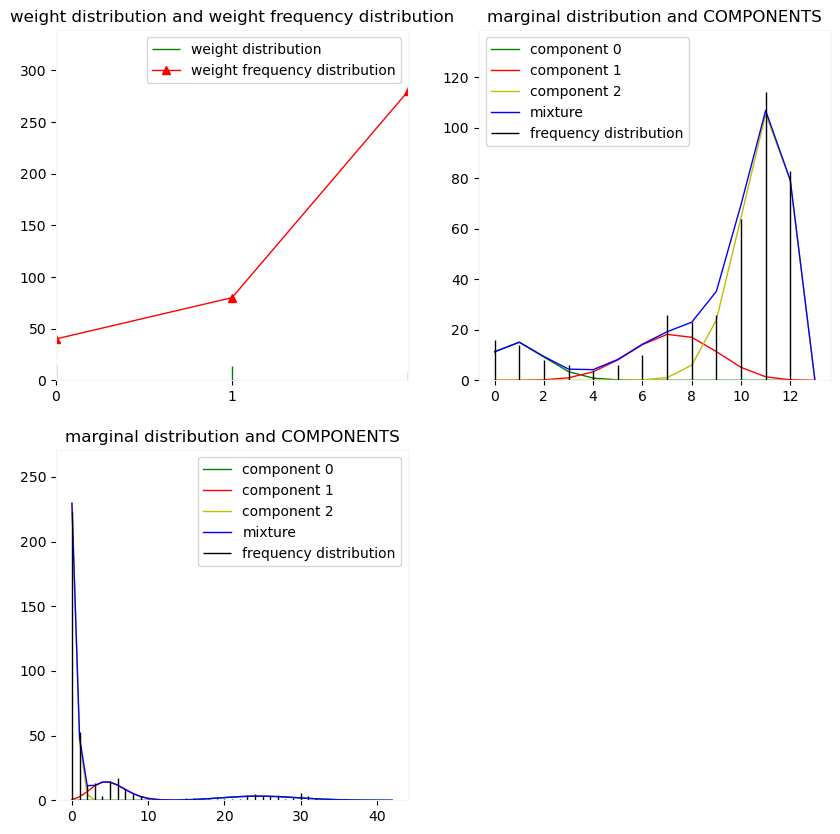

In [20]:
Plot(simulation_MultiM)

... and multivariate mixtures estimated from data.

In [21]:
MM_est = simulation_MultiM.mixture_estimation(MultiM, 100,  [True, True])

Warning. Empty data.


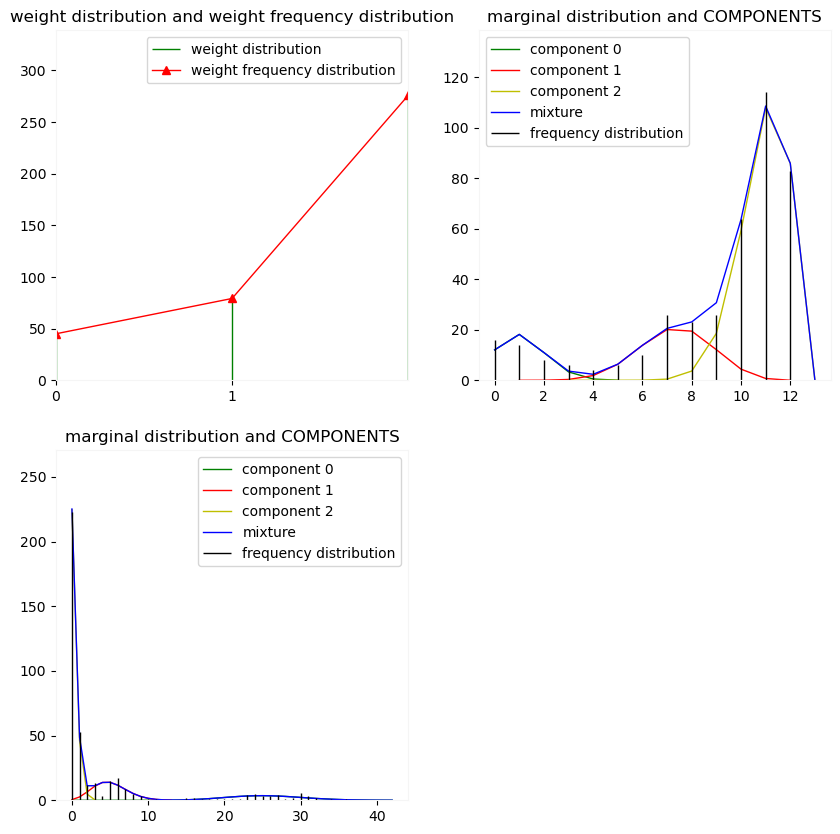

In [22]:
Plot(MM_est)

**TODO**: explore the other possible arguments of mixture_estimation.

## Plotting Compound Distributions

Using the Plot function on a Compound object yields the probability mass function of the compound, the sum and the elementary distributions:

In [23]:
X = NegativeBinomial(0, 1, 0.1)
N = Binomial(0, 10, 0.5)
comp1 = Compound(N, X)

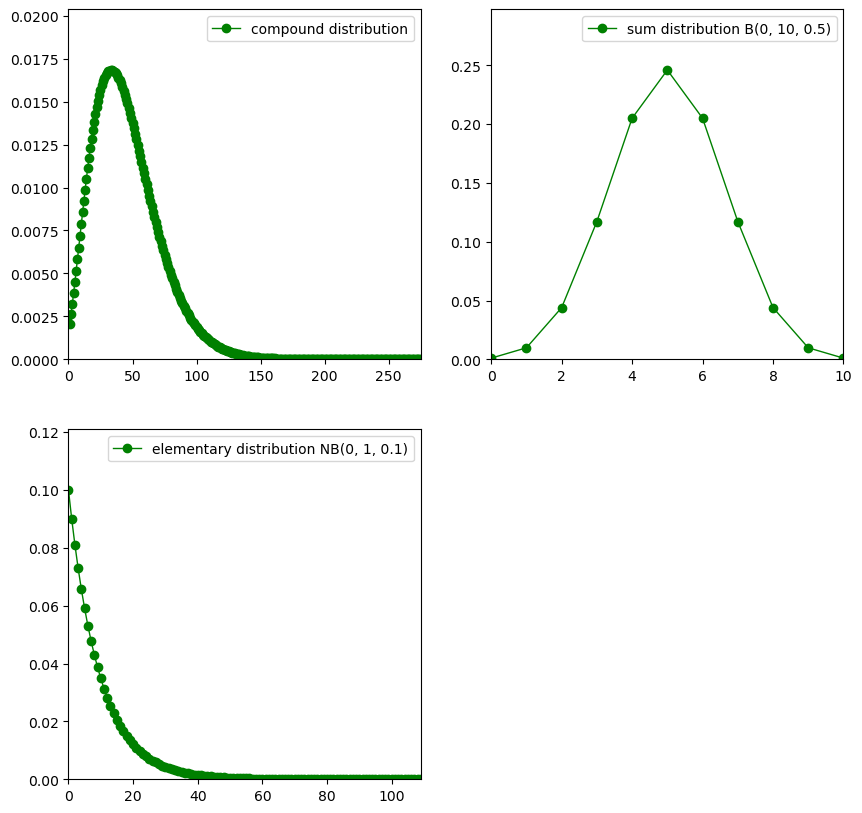

In [24]:
Plot(comp1)

A similar principle holds when plotting samples issued from a Compound object...

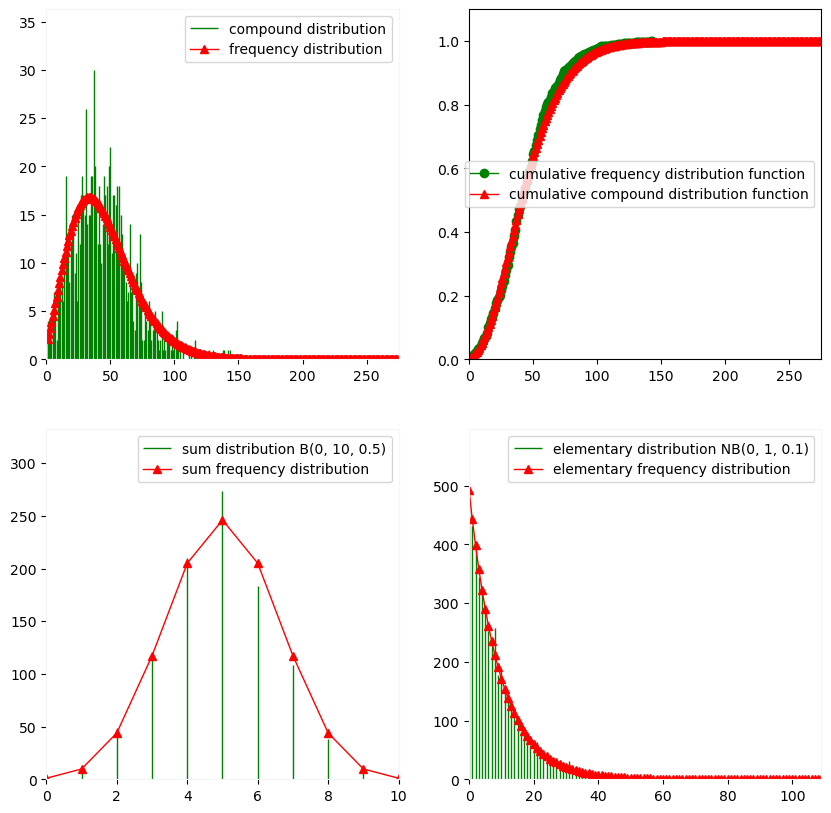

In [25]:
set_seed(0)
simulation_comp = comp1.simulate(1000)
Plot(simulation_comp)

In [26]:
comp_est = Estimate(simulation_comp, "COMPOUND",
                    ExtractDistribution(comp1, "Sum"),
                    "Sum",
                    InitialDistribution=ExtractDistribution(comp1, "Elementary"))

and plotting a Compound object estimated from samples.

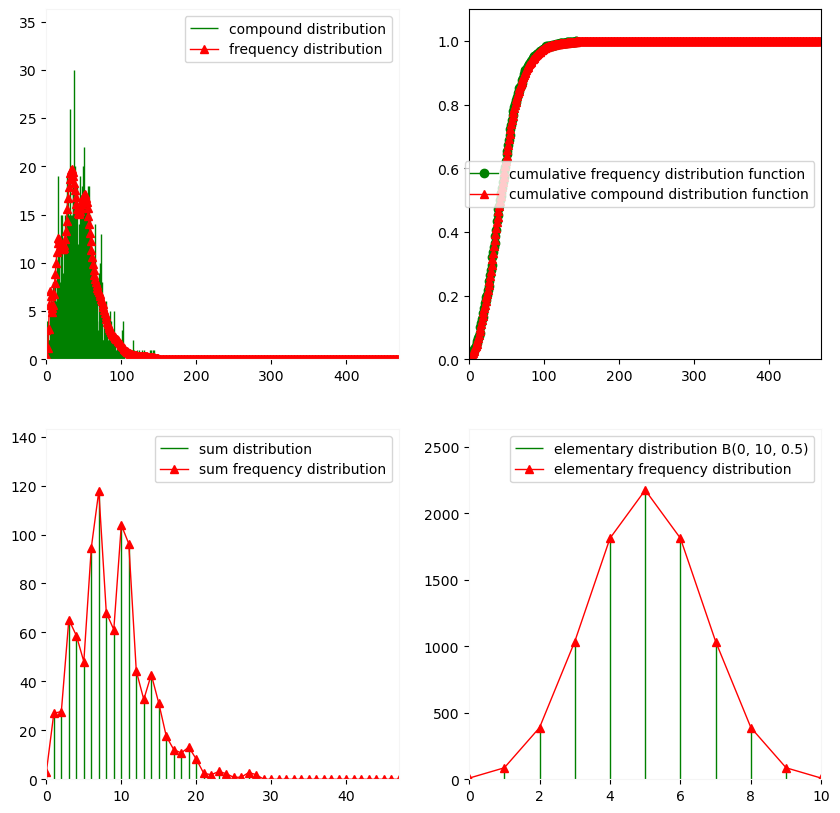

In [27]:
Plot(comp_est)

**TODO**: convolution